# Predicting from a continuous connectome, with every fit inside the folds

A connectome predicts a trait only if everything learned from the data is learned without the
subjects it is tested on. For a continuous connectome that includes the functional PCA basis and
the cohort mean it is centred on, as well as the scaling, the model and its penalty; and with
twins and siblings in the cohort, a family has to stay on one side of every split. This notebook
does all of it for 300 HCP young adults and two traits, sex and fluid intelligence (the number
of PMAT24 items answered correctly), from the continuous connectome's component scores and,
beside them, from the Schaefer-200 region matrices of the same files.

`scripts/prediction_data.py` draws the sample family by family, deals the families to five
folds, and fits a rank-15 basis to each fold's training subjects, scoring all 300 on it (about
an hour a fold on the cluster). Everything else happens here, in about 23 minutes on 8 cores
and 2 GB of memory. The families are restricted HCP data: they are read from outside the
repository, and only counts appear below.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# The lab's copies on Longleaf; point these at your own files.
ROOT = Path("/work/users/x/y/xya/hcp-ya")
DATA = ROOT / "prediction"  # what scripts/prediction_data.py wrote
TRAITS = ROOT / "open_access_traits.csv"  # subject, sex, age_bin, fluid_intelligence_pmat24
FAMILIES = ROOT / "restricted" / "families.csv"  # restricted HCP data: read here, never shown
FOLDS, RANK = 5, 15

BLUE, ORANGE, INK, MUTED, RULE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#d9d8d3"
plt.rcParams.update({
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": RULE,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": MUTED,
    "ytick.color": MUTED, "figure.facecolor": "white", "figure.dpi": 110,
})

## 1. The sample and its folds

Three hundred subjects in 134 families: 27 alone, 56 pairs, 43 of three and 8 of four. Dealt
whole to five folds of 60, no family has members in two folds. Men are 48% of the sample, and
fluid intelligence averages 16.9 of 24 (sd 4.9). Head size will matter: the brain-mask volume
averages 1.74 L in men and 1.50 L in women.

In [2]:
with open(DATA / "sample.csv", newline="") as handle:
    rows = list(csv.DictReader(handle))
subjects = np.array([row["subject"] for row in rows])
fold = np.array([int(row["fold"]) for row in rows])
with open(TRAITS, newline="") as handle:
    traits = {row["subject"]: row for row in csv.DictReader(handle)}
with open(FAMILIES, newline="") as handle:
    family_of = {row["subject"]: row["group"] for row in csv.DictReader(handle)}
family = np.unique([family_of[s] for s in subjects], return_inverse=True)[1]  # codes 0, 1, ...
del family_of

men = np.array([traits[s]["sex"] == "M" for s in subjects], dtype=int)
pmat = np.array([float(traits[s]["fluid_intelligence_pmat24"]) for s in subjects])
BAND = {"22-25": 23.5, "26-30": 28.0, "31-35": 33.0, "36+": 37.0}
age = np.array([BAND[traits[s]["age_bin"]] for s in subjects])
covariates = np.load(DATA / "covariates.npz")
assert (covariates["subjects"] == subjects).all()
head = np.column_stack([covariates["brain_volume"], covariates["streamlines"]])

sizes = np.bincount(np.bincount(family))
print(f"{subjects.size} subjects in {family.max() + 1} families, of "
      + ", ".join(f"{size} ({count})" for size, count in enumerate(sizes) if size and count)
      + " members (how many families)")
assert all(len(set(fold[family == f])) == 1 for f in range(family.max() + 1))
print(f"{FOLDS} folds of {np.bincount(fold).tolist()} subjects; no family is split between two")
print(f"{men.mean():.0%} men; PMAT24 {pmat.mean():.1f} correct of 24 on average (sd {pmat.std():.1f})")
print(f"brain-mask volume {head[men == 1, 0].mean():.2f} L in men on average, "
      f"{head[men == 0, 0].mean():.2f} L in women")

300 subjects in 134 families, of 1 (27), 2 (56), 3 (43), 4 (8) members (how many families)
5 folds of [60, 60, 60, 60, 60] subjects; no family is split between two
48% men; PMAT24 16.9 correct of 24 on average (sd 4.9)
brain-mask volume 1.74 L in men on average, 1.50 L in women


## 2. Features, each fitted on training subjects alone

For each fold the basis comes from its 240 training subjects alone, and captures 26.0% to 26.4%
of their norm in 15 components; the 60 held-out subjects are scored on it with `sbci.project`,
exactly as the training subjects are. The Schaefer-200 matrices hold each pair of regions' share
of the connectome's unit mass, 19,900 pairs a subject. They are logged, one fixed transform for
everyone, then standardised and reduced by a PCA fitted to each fold's training subjects alone
and scored on everyone, as the components are, so that the two are tuned alike.

In [3]:
position = {subject: i for i, subject in enumerate(subjects)}
component_scores = []
for k in range(FOLDS):
    data = np.load(DATA / f"fold{k}.npz")
    assert set(data["test"]) == set(subjects[fold == k]) and set(data["train"]) == set(subjects[fold != k])
    scores = np.empty((subjects.size, RANK))
    scores[[position[s] for s in data["train"]]] = data["train_scores"]
    scores[[position[s] for s in data["test"]]] = data["test_scores"]
    component_scores.append(scores)  # fold k's basis: every subject scored on it
    print(f"fold {k}: basis from {data['train'].size} subjects, {data['explained'][-1]:.1%} of their norm "
          f"in {RANK} components")

atlas = np.load(DATA / "atlas.npz")
assert (atlas["subjects"] == subjects).all()
masses = atlas["schaefer200"]  # each pair of regions' share of the connectome's unit mass
print(f"Schaefer-200: {masses.shape[1]:,} region pairs a subject, {np.mean(masses == 0):.1%} of them zero")


def region_scores(values, train, standardise=True):
    """A PCA of the region pairs fitted on the training subjects alone, every subject scored on it."""
    steps = [StandardScaler()] if standardise else []
    return make_pipeline(*steps, PCA(n_components=RANK, random_state=0)).fit(values[train]).transform(values)


# Region masses span orders of magnitude, and a few are zero: their logarithm, one fixed transform
# for everyone, comes first; the scaling and the PCA are fitted inside each fold, as the basis is.
logged = np.log10(masses + 1e-9)
SCORES = {
    "continuous": component_scores,
    "regions": [region_scores(logged, fold != k) for k in range(FOLDS)],
}

fold 0: basis from 240 subjects, 26.3% of their norm in 15 components
fold 1: basis from 240 subjects, 26.4% of their norm in 15 components
fold 2: basis from 240 subjects, 26.1% of their norm in 15 components
fold 3: basis from 240 subjects, 26.2% of their norm in 15 components
fold 4: basis from 240 subjects, 26.0% of their norm in 15 components


Schaefer-200: 19,900 region pairs a subject, 9.5% of them zero


## 3. One procedure for every model

Every model is fitted the same way. In each of the five outer folds a grid search over a
four-fold split of the training subjects, by family, chooses how many components to use (1 to
15) and the penalty; the scaling is fitted on the training subjects; and the held-out fold is
predicted once. Each fold's AUC or r is computed on its own 60 held-out subjects, and the five
are averaged. Pooled across folds instead, a weak model's r and AUC fall below their null --
each fold's predictions lean towards its training subjects' mean, opposite to its own -- and by
an amount that depends on how the subjects were dealt. Intervals resample whole families within
each fold; a difference between two models gets a paired interval, both resampled alike.

In [4]:
class First(BaseEstimator, TransformerMixin):
    """The first k of the leading n columns (component scores), and every column after them."""

    def __init__(self, k=RANK, n=RANK):
        self.k, self.n = k, n

    def fit(self, x, y=None):
        self.n_features_in_ = x.shape[1]  # what marks a scikit-learn step as fitted
        return self

    def transform(self, x):
        return np.hstack([x[:, : self.k], x[:, self.n :]])


COMPONENTS = [1, 2, 3, 5, 8, 10, 15]
PENALTY = {"sex": {"logisticregression__C": np.logspace(-3, 2, 6)},
           "pmat": {"ridge__alpha": np.logspace(-1, 5, 7)}}


def estimator(target):
    return LogisticRegression(max_iter=10_000) if target == "sex" else Ridge()


def out_of_fold(features, target, extra):
    """Every subject's prediction from a model chosen, scaled and fitted without its fold.

    The outer folds are the sample's, families kept whole; inside each training fold a
    four-fold split by family chooses the number of components and the penalty.
    """
    y = men if target == "sex" else pmat
    predicted, chosen = np.empty(y.size), []
    for k in range(FOLDS):
        train, test = fold != k, fold == k
        if features == "covariates":
            pipeline, grid, x = make_pipeline(StandardScaler(), estimator(target)), PENALTY[target], extra
        else:
            pipeline = make_pipeline(First(), StandardScaler(), estimator(target))
            grid, x = {"first__k": COMPONENTS, **PENALTY[target]}, np.hstack([SCORES[features][k], extra])
        search = GridSearchCV(pipeline, grid, cv=GroupKFold(n_splits=4), n_jobs=-1,
                              scoring="roc_auc" if target == "sex" else "r2")
        search.fit(x[train], y[train], groups=family[train])
        predicted[test] = (search.predict_proba(x[test])[:, 1] if target == "sex"
                           else search.predict(x[test]))
        chosen.append({key.split("__")[-1]: value for key, value in search.best_params_.items()})
    return predicted, chosen


def pearson(y, predicted):
    return float(np.corrcoef(y, predicted)[0, 1])


def per_fold(metric, y, predicted, folds=None):
    """The metric in each fold, averaged: pooled across folds, a weak model's r and AUC fall below
    their null, since each fold's predictions lean to its training subjects' mean."""
    folds = fold if folds is None else folds
    return float(np.mean([metric(y[folds == k], predicted[folds == k]) for k in range(FOLDS)]))


# Bootstrap draws that resample whole families within each fold, the same draws for every model,
# so that two models' difference has a paired interval.
rng = np.random.default_rng(0)
groups = [[np.flatnonzero(family == f) for f in np.unique(family[fold == k])] for k in range(FOLDS)]
DRAWS = [[np.concatenate([g[i] for i in rng.integers(0, len(g), len(g))]) for g in groups]
         for _ in range(2000)]


def interval(metric, y, first, second=None):
    """A 95% interval for the per-fold mean, or for the first model's less the second's."""
    def at(draw, predicted):
        return np.mean([metric(y[index], predicted[index]) for index in draw])
    values = [at(draw, first) - (at(draw, second) if second is not None else 0.0) for draw in DRAWS]
    return np.percentile(values, [2.5, 97.5])


def chosen_text(chosen):
    """What the inner folds chose in each outer fold: components, and the penalty."""
    penalty = "C" if "C" in chosen[0] else "alpha"
    return "chosen: " + "; ".join((f"{c['k']} at " if "k" in c else "") + f"{penalty} {c[penalty]:g}"
                                  for c in chosen)


def compare(results, y, metric, label, pairs):
    for first, second in pairs:
        difference = per_fold(metric, y, results[first]) - per_fold(metric, y, results[second])
        low, high = interval(metric, y, results[first], results[second])
        print(f"  {first} less {second}: {label} {difference:+.3f} (95% interval {low:+.3f} to {high:+.3f})")

## 4. Sex, and how much of it is head size

Sex is predicted mostly by head size here. Brain-mask volume and streamline count alone reach an
AUC of 0.920 (0.881 to 0.956). The continuous components alone reach 0.658 (0.587 to 0.728), and
the Schaefer-200 regions 0.865 (0.819 to 0.907): the regions lead the components by 0.21 (paired
interval 0.12 to 0.29). Added to head size, the components change nothing (-0.011, -0.029 to
+0.005), while the regions add a little, +0.034 (+0.010 to +0.062), to 0.954.

In [5]:
none = np.empty((subjects.size, 0))
sex_models = {
    "head size and streamlines": ("covariates", head),
    "continuous": ("continuous", none),
    "continuous, with head size": ("continuous", head),
    "Schaefer-200": ("regions", none),
    "Schaefer-200, with head size": ("regions", head),
}
sex_predicted, sex_chosen, sex_results = {}, {}, {}
for name, (features, extra) in sex_models.items():
    sex_predicted[name], sex_chosen[name] = out_of_fold(features, "sex", extra)
    value = per_fold(roc_auc_score, men, sex_predicted[name])
    low, high = interval(roc_auc_score, men, sex_predicted[name])
    sex_results[name] = (value, low, high)
    print(f"{name:29s} AUC {value:.3f} (95% interval {low:.3f} to {high:.3f}); {chosen_text(sex_chosen[name])}")
compare(sex_predicted, men, roc_auc_score, "AUC", [
    ("continuous, with head size", "head size and streamlines"),
    ("Schaefer-200, with head size", "head size and streamlines"),
    ("Schaefer-200", "continuous"),
])

head size and streamlines     AUC 0.920 (95% interval 0.881 to 0.956); chosen: C 0.001; C 0.1; C 0.1; C 10; C 1


continuous                    AUC 0.658 (95% interval 0.587 to 0.728); chosen: 10 at C 1; 15 at C 0.1; 10 at C 0.1; 10 at C 0.01; 15 at C 100


continuous, with head size    AUC 0.909 (95% interval 0.858 to 0.952); chosen: 3 at C 100; 8 at C 0.1; 5 at C 0.01; 10 at C 1; 1 at C 0.001


Schaefer-200                  AUC 0.865 (95% interval 0.819 to 0.907); chosen: 15 at C 10; 15 at C 1; 15 at C 100; 15 at C 0.01; 15 at C 0.1


Schaefer-200, with head size  AUC 0.954 (95% interval 0.932 to 0.975); chosen: 15 at C 0.1; 10 at C 0.01; 15 at C 0.01; 10 at C 1; 10 at C 0.1


  continuous, with head size less head size and streamlines: AUC -0.011 (95% interval -0.029 to +0.005)


  Schaefer-200, with head size less head size and streamlines: AUC +0.034 (95% interval +0.010 to +0.062)


  Schaefer-200 less continuous: AUC +0.208 (95% interval +0.121 to +0.293)


## 5. Fluid intelligence

Fluid intelligence is not predictable from either connectome in this sample. Sex, age band, head
size and streamline count together give r = 0.335 (0.218 to 0.438). The continuous components
alone give 0.038 (-0.082 to 0.155) and the regions 0.044 (-0.083 to 0.164), and added to the
covariates neither helps (-0.045, -0.104 to +0.010; -0.017, -0.071 to +0.036).

In [6]:
demographic = np.column_stack([men, age, head])
pmat_models = {
    "sex, age band, head size, streamlines": ("covariates", demographic),
    "continuous": ("continuous", none),
    "continuous, with those": ("continuous", demographic),
    "Schaefer-200": ("regions", none),
    "Schaefer-200, with those": ("regions", demographic),
}
pmat_predicted, pmat_chosen, pmat_results = {}, {}, {}
for name, (features, extra) in pmat_models.items():
    pmat_predicted[name], pmat_chosen[name] = out_of_fold(features, "pmat", extra)
    value = per_fold(pearson, pmat, pmat_predicted[name])
    low, high = interval(pearson, pmat, pmat_predicted[name])
    pmat_results[name] = (value, low, high)
    print(f"{name:37s} r {value:6.3f} (95% interval {low:6.3f} to {high:6.3f}); {chosen_text(pmat_chosen[name])}")
compare(pmat_predicted, pmat, pearson, "r", [
    ("continuous, with those", "sex, age band, head size, streamlines"),
    ("Schaefer-200, with those", "sex, age band, head size, streamlines"),
    ("Schaefer-200", "continuous"),
])

sex, age band, head size, streamlines r  0.335 (95% interval  0.218 to  0.438); chosen: alpha 10; alpha 10; alpha 10; alpha 10; alpha 10


continuous                            r  0.038 (95% interval -0.082 to  0.155); chosen: 8 at alpha 100; 8 at alpha 100000; 8 at alpha 1000; 5 at alpha 100; 15 at alpha 1000


continuous, with those                r  0.290 (95% interval  0.170 to  0.395); chosen: 8 at alpha 100; 1 at alpha 100; 5 at alpha 10; 5 at alpha 10; 2 at alpha 10


Schaefer-200                          r  0.044 (95% interval -0.083 to  0.164); chosen: 5 at alpha 100; 5 at alpha 100; 15 at alpha 1000; 1 at alpha 100; 3 at alpha 100


Schaefer-200, with those              r  0.318 (95% interval  0.195 to  0.421); chosen: 1 at alpha 10; 5 at alpha 10; 1 at alpha 10; 1 at alpha 10; 3 at alpha 10


  continuous, with those less sex, age band, head size, streamlines: r -0.045 (95% interval -0.104 to +0.010)


  Schaefer-200, with those less sex, age band, head size, streamlines: r -0.017 (95% interval -0.071 to +0.036)


  Schaefer-200 less continuous: r +0.006 (95% interval -0.160 to +0.178)


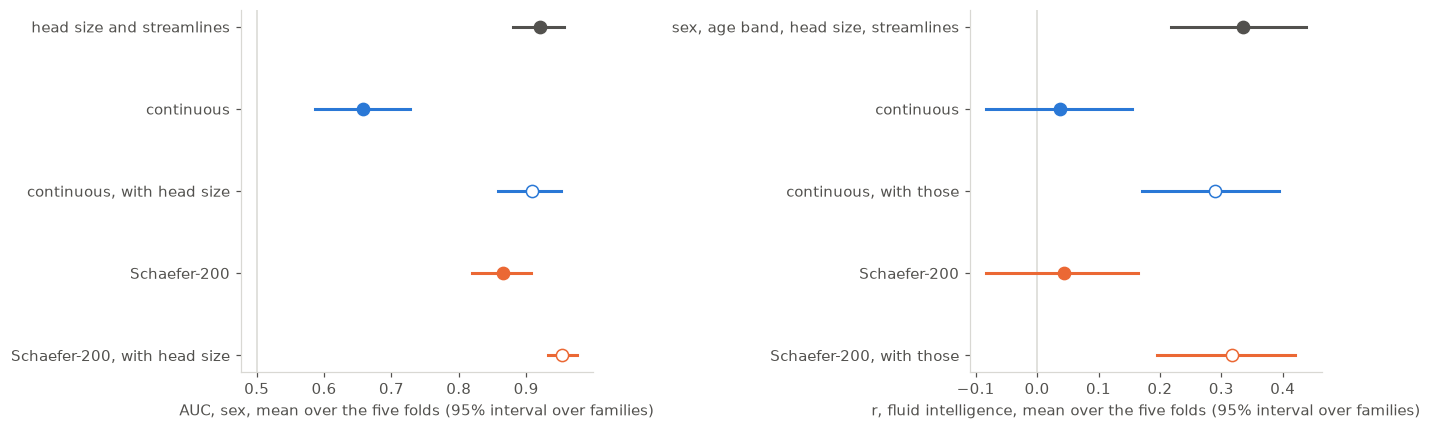

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
figure.get_layout_engine().set(wspace=0.12)
for axis, results, label, chance in ((left, sex_results, "AUC, sex", 0.5),
                                     (right, pmat_results, "r, fluid intelligence", 0.0)):
    names = list(results)[::-1]
    for row, name in enumerate(names):
        value, low, high = results[name]
        colour = BLUE if name.startswith("continuous") else ORANGE if name.startswith("Schaefer") else MUTED
        axis.plot([low, high], [row, row], color=colour, linewidth=2)
        axis.plot(value, row, "o", color=colour, markersize=8,
                  markerfacecolor="white" if "with" in name else colour)
    axis.axvline(chance, color=RULE, linewidth=1, zorder=0)
    axis.set_yticks(range(len(names)), names)
    axis.set_xlabel(f"{label}, mean over the five folds (95% interval over families)")
plt.show()

## 6. Why the components trail the regions

Part of the regions' lead on sex is their transform. Their masses are logged and standardised
before the PCA; a PCA of the raw masses, as the functional PCA takes the raw continuous
densities, reaches 0.793 (0.737 to 0.845), so the transform is worth 0.072 (0.015 to 0.134). The
raw masses still lead the components by 0.136 (0.065 to 0.207). That remainder lies in the
reductions themselves: each functional component is separable, a product of one surface map
with itself, fitted to reconstruct the connectome, where the regions' PCA weighs 19,900 pairs in
any direction; fifteen such components carry less of what tells the sexes apart.

In [8]:
SCORES["raw masses"] = [region_scores(masses, fold != k, standardise=False) for k in range(FOLDS)]
raw, _ = out_of_fold("raw masses", "sex", none)
value = per_fold(roc_auc_score, men, raw)
low, high = interval(roc_auc_score, men, raw)
print(f"Schaefer-200, a PCA of the raw masses: sex AUC {value:.3f} (95% interval {low:.3f} to {high:.3f})")
compare({"logged and standardised": sex_predicted["Schaefer-200"], "raw masses": raw,
         "the continuous components": sex_predicted["continuous"]}, men, roc_auc_score, "AUC",
        [("logged and standardised", "raw masses"), ("raw masses", "the continuous components")])

Schaefer-200, a PCA of the raw masses: sex AUC 0.793 (95% interval 0.737 to 0.845)


  logged and standardised less raw masses: AUC +0.072 (95% interval +0.015 to +0.134)


  raw masses less the continuous components: AUC +0.136 (95% interval +0.065 to +0.207)


## 7. What keeping families whole is for

Keeping families whole matters where a trait runs in families. The subjects are dealt to folds
twenty times with families kept whole and twenty times at random, which splits 94 of the 134
families on average, and one fixed model -- all fifteen components, with a penalty set in
advance -- is scored both ways. For fluid intelligence, splitting families raises the per-fold
r by 0.045 on average, from 0.072 to 0.117 (sd 0.042 over the dealings), where features that
cannot leak -- random numbers, drawn afresh for each dealing -- move by +0.001 (sd 0.047):
twins and siblings on both sides of a split pass the model a little of each other's score. For
sex the two agree (+0.004), and the random numbers sit at chance, 0.50, either way.

In [9]:
def dealt_folds(assignment, target, x, penalty):
    """Per-fold mean of a fixed model -- all fifteen components and one penalty -- over one dealing."""
    y = men if target == "sex" else pmat
    predicted = np.empty(y.size)
    for k in range(FOLDS):
        train, test = assignment != k, assignment == k
        scores = region_scores(x, train) if x.shape[1] > RANK else x
        model = (LogisticRegression(C=penalty, max_iter=10_000) if target == "sex" else Ridge(alpha=penalty))
        fitted = make_pipeline(StandardScaler(), model).fit(scores[train], y[train])
        predicted[test] = (fitted.predict_proba(scores[test])[:, 1] if target == "sex"
                           else fitted.predict(scores[test]))
    metric = roc_auc_score if target == "sex" else pearson
    return per_fold(metric, y, predicted, folds=assignment)


REPEATS = 20
FIXED = {"sex": ("C", 1.0), "pmat": ("alpha", 100.0)}  # set in advance, the middle of the grids
dealings = []
for seed in range(REPEATS):
    rng = np.random.default_rng(seed)
    dealt = rng.permutation(family.max() + 1) % FOLDS  # each family to a fold at random
    shuffled = rng.permutation(subjects.size) % FOLDS  # each subject, families ignored
    noise = rng.standard_normal((subjects.size, RANK))  # features with nothing to leak, drawn afresh
    dealings.append((dealt[family], shuffled, noise))
straddling = np.mean([sum(len(set(shuffled[family == f])) > 1 for f in range(family.max() + 1))
                      for _, shuffled, _ in dealings])
print(f"split at random, {straddling:.0f} of the {family.max() + 1} families straddle folds on average")
for target, label in (("sex", "sex, AUC"), ("pmat", "fluid intelligence, r")):
    key, penalty = FIXED[target]
    for features in ("Schaefer-200", "random numbers"):
        regions = features == "Schaefer-200"
        whole = np.array([dealt_folds(kept, target, logged if regions else noise, penalty)
                          for kept, _, noise in dealings])
        split = np.array([dealt_folds(shuffled, target, logged if regions else noise, penalty)
                          for _, shuffled, noise in dealings])
        gap = split - whole
        print(f"{label:22s} from {features:14s} (all {RANK} components, {key} {penalty:g}): "
              f"{whole.mean():.3f} with families kept whole, {split.mean():.3f} with them split; "
              f"split less whole {gap.mean():+.3f} (sd {gap.std():.3f} over {REPEATS} dealings)")

split at random, 94 of the 134 families straddle folds on average


sex, AUC               from Schaefer-200   (all 15 components, C 1): 0.852 with families kept whole, 0.856 with them split; split less whole +0.004 (sd 0.013 over 20 dealings)


sex, AUC               from random numbers (all 15 components, C 1): 0.504 with families kept whole, 0.495 with them split; split less whole -0.009 (sd 0.033 over 20 dealings)


fluid intelligence, r  from Schaefer-200   (all 15 components, alpha 100): 0.072 with families kept whole, 0.117 with them split; split less whole +0.045 (sd 0.042 over 20 dealings)


fluid intelligence, r  from random numbers (all 15 components, alpha 100): -0.016 with families kept whole, -0.015 with them split; split less whole +0.001 (sd 0.047 over 20 dealings)


## What this says

- **Fit everything inside the training folds, keep families whole, and score each fold on its
  own.** Splitting families raised fluid intelligence's r by 0.045 on average, a small leak but
  a systematic one; pooled across folds, a weak model's r and AUC sit below their null, by an
  amount that depends on the dealing.
- **Check what the covariates alone do.** Sex here is head size first (AUC 0.92); the regions
  add a little to it (+0.034), the components nothing.
- **At rank 15 the continuous components carry less about sex than a parcellation's PCA** (AUC
  0.66 against 0.87): the regions' log transform accounts for 0.07 of it, the reductions
  themselves the rest. Fluid intelligence is out of reach of both with 300 subjects.